# Result Notebook

This notebook centralizes the result tables and figure regeneration workflow used by `liuthesis_my/Result.tex`.
It uses existing result artifacts as inputs, keeps figure-generation logic in external Python modules, and displays the generated figures inside the notebook.


## 1. Setup

The notebook imports shared path helpers and the figure generators, then prepares a few utility functions for loading result files and displaying generated images.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT_HINTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/liuxi/Desktop/UPert"),
]

def detect_root(candidates):
    for candidate in candidates:
        candidate = Path(candidate).resolve()
        if (candidate / "liuthesis_my" / "Result.tex").exists():
            return candidate
    raise FileNotFoundError("Could not detect project root containing liuthesis_my/Result.tex")

ROOT = detect_root(ROOT_HINTS)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from plot.common import project_paths
from plot import (
    generate_benchmark_mean_baseline_figures,
    generate_data_efficiency_figure,
    generate_gene_distribution_figure,
    generate_gene_level_uncertainty_figure,
    generate_uncertainty_figures,
)
from src.plot import plot_benchmark_scatter

PATHS = project_paths(ROOT)
ROOT = PATHS["root"]
FIG_DIR = PATHS["fig_dir"]
OUTPUTS_DIR = PATHS["outputs_dir"]
RESULTS_DIR = PATHS["results_dir"]
DATA_DIR = PATHS["data_dir"]

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print(f"ROOT = {ROOT}")
print(f"FIG_DIR = {FIG_DIR}")


ROOT = /Users/liuxi/Desktop/UPert
FIG_DIR = /Users/liuxi/Desktop/UPert/liuthesis_my/figures


## 2. Helpers


In [2]:
DISPLAY_SPLITS = {
    "warm": "Warm",
    "cold_target_pattern": "Cold drug target",
    "cold_cell": "Cold cell",
}

def split_display_name(split_key: str) -> str:
    return DISPLAY_SPLITS.get(split_key, split_key)

def load_json(path: Path):
    with Path(path).open("r", encoding="utf-8") as handle:
        return json.load(handle)

def load_npz(path: Path):
    data = np.load(path, allow_pickle=True)
    return {key: data[key] for key in data.files}

def result_list_to_map(bundle):
    return {item["split_mode"]: item for item in bundle.get("results", [])}

def topk_precision(y_true, y_pred, k=20):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    pos_scores = []
    neg_scores = []
    for i in range(y_true.shape[0]):
        true_pos = set(np.argsort(-y_true[i])[:k].tolist())
        pred_pos = set(np.argsort(-y_pred[i])[:k].tolist())
        true_neg = set(np.argsort(y_true[i])[:k].tolist())
        pred_neg = set(np.argsort(y_pred[i])[:k].tolist())
        pos_scores.append(len(true_pos & pred_pos) / float(k))
        neg_scores.append(len(true_neg & pred_neg) / float(k))
    return float(np.mean(pos_scores)), float(np.mean(neg_scores))

def sign_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))

def show_image(path, width=950):
    image_path = Path(path)
    if not image_path.exists():
        raise FileNotFoundError(image_path)
    display(Image(filename=str(image_path), width=width))

def show_paths(paths):
    if isinstance(paths, (str, Path)):
        print(Path(paths))
        return
    for path in paths:
        print(Path(path))


## 3. Outputs


In [3]:
ARTIFACTS = {
    "uptert_no_cf_meta": {
        "warm": OUTPUTS_DIR / "no_cf_0523" / "ugat_no_cf_uncertainty_sparse.meta.warm.json",
        "cold_target_pattern": OUTPUTS_DIR / "no_cf_0523" / "ugat_no_cf_uncertainty_sparse.meta.cold_target_pattern.json",
        "cold_cell": OUTPUTS_DIR / "no_cf_0523" / "ugat_no_cf_uncertainty_sparse.meta.cold_cell.json",
    },
    "uptert_no_cf_npz": {
        "warm": OUTPUTS_DIR / "no_cf_0523" / "ugat_no_cf_uncertainty_sparse.eval.warm.npz",
        "cold_target_pattern": OUTPUTS_DIR / "no_cf_0523" / "ugat_no_cf_uncertainty_sparse.eval.cold_target_pattern.npz",
        "cold_cell": OUTPUTS_DIR / "no_cf_0523" / "ugat_no_cf_uncertainty_sparse.eval.cold_cell.npz",
    },
    "uptert_cf_meta": {
        "warm": OUTPUTS_DIR / "with_cf_gat_0524" / "cagnn_control_context.meta.warm.json",
        "cold_target_pattern": OUTPUTS_DIR / "with_cf_gat_0524" / "cagnn_control_context.meta.cold_target_pattern.json",
        "cold_cell": OUTPUTS_DIR / "with_cf_gat_0524" / "cagnn_control_context.meta.cold_cell.json",
    },
    "uptert_cf_npz": {
        "warm": OUTPUTS_DIR / "with_cf_gat_0524" / "cagnn_control_context.eval.warm.npz",
        "cold_target_pattern": OUTPUTS_DIR / "with_cf_gat_0524" / "cagnn_control_context.eval.cold_target_pattern.npz",
        "cold_cell": OUTPUTS_DIR / "with_cf_gat_0524" / "cagnn_control_context.eval.cold_cell.npz",
    },
    "deepcop_json": OUTPUTS_DIR / "deepcop_uncertainty_0524" / "deepcop_uncertainty.json",
    "gsnn_json": OUTPUTS_DIR / "gsnn_0524" / "gsnn_results.json",
}

for key, value in ARTIFACTS.items():
    if isinstance(value, dict):
        for split, path in value.items():
            print(f"{key}:{split} -> {path.exists()} :: {path}")
    else:
        print(f"{key} -> {value.exists()} :: {value}")


uptert_no_cf_meta:warm -> True :: /Users/liuxi/Desktop/UPert/outputs/no_cf_0523/ugat_no_cf_uncertainty_sparse.meta.warm.json
uptert_no_cf_meta:cold_target_pattern -> True :: /Users/liuxi/Desktop/UPert/outputs/no_cf_0523/ugat_no_cf_uncertainty_sparse.meta.cold_target_pattern.json
uptert_no_cf_meta:cold_cell -> True :: /Users/liuxi/Desktop/UPert/outputs/no_cf_0523/ugat_no_cf_uncertainty_sparse.meta.cold_cell.json
uptert_no_cf_npz:warm -> True :: /Users/liuxi/Desktop/UPert/outputs/no_cf_0523/ugat_no_cf_uncertainty_sparse.eval.warm.npz
uptert_no_cf_npz:cold_target_pattern -> True :: /Users/liuxi/Desktop/UPert/outputs/no_cf_0523/ugat_no_cf_uncertainty_sparse.eval.cold_target_pattern.npz
uptert_no_cf_npz:cold_cell -> True :: /Users/liuxi/Desktop/UPert/outputs/no_cf_0523/ugat_no_cf_uncertainty_sparse.eval.cold_cell.npz
uptert_cf_meta:warm -> True :: /Users/liuxi/Desktop/UPert/outputs/with_cf_gat_0524/cagnn_control_context.meta.warm.json
uptert_cf_meta:cold_target_pattern -> True :: /Users/liu

## 4. Load Results


In [4]:
uptert_no_cf_meta = {
    split: load_json(path)
    for split, path in ARTIFACTS["uptert_no_cf_meta"].items()
    if path.exists()
}
uptert_cf_meta = {
    split: load_json(path)
    for split, path in ARTIFACTS["uptert_cf_meta"].items()
    if path.exists()
}
uptert_no_cf_npz = {
    split: load_npz(path)
    for split, path in ARTIFACTS["uptert_no_cf_npz"].items()
    if path.exists()
}
uptert_cf_npz = {
    split: load_npz(path)
    for split, path in ARTIFACTS["uptert_cf_npz"].items()
    if path.exists()
}
deepcop_meta = (
    result_list_to_map(load_json(ARTIFACTS["deepcop_json"]))
    if ARTIFACTS["deepcop_json"].exists()
    else {}
)
gsnn_meta = (
    result_list_to_map(load_json(ARTIFACTS["gsnn_json"]))
    if ARTIFACTS["gsnn_json"].exists()
    else {}
)

artifact_summary = pd.DataFrame(
    {
        "artifact": [
            "UPert no-CF meta",
            "UPert CF meta",
            "UPert no-CF npz",
            "UPert CF npz",
            "DeepCOP meta",
            "GSNN meta",
        ],
        "splits": [
            ", ".join(uptert_no_cf_meta.keys()),
            ", ".join(uptert_cf_meta.keys()),
            ", ".join(uptert_no_cf_npz.keys()),
            ", ".join(uptert_cf_npz.keys()),
            ", ".join(deepcop_meta.keys()),
            ", ".join(gsnn_meta.keys()),
        ],
    }
)
display(artifact_summary)


,artifact,splits
0,UPert no-CF meta,"warm, cold_target_pattern, cold_cell"
1,UPert CF meta,"warm, cold_target_pattern, cold_cell"
2,UPert no-CF npz,"warm, cold_target_pattern, cold_cell"
3,UPert CF npz,"warm, cold_target_pattern, cold_cell"
4,DeepCOP meta,"warm, cold_target_pattern, cold_cell"
5,GSNN meta,"warm, cold_target_pattern, cold_cell"


## 5. Benchmark Tables


In [5]:
def build_learned_metric_table(metric_key):
    rows = []
    for split in ["warm", "cold_target_pattern", "cold_cell"]:
        row = {"Split": split_display_name(split)}
        if split in deepcop_meta:
            row["DeepCOP"] = float(deepcop_meta[split]["test_metrics"][metric_key])
        if split in gsnn_meta:
            row["GSNN"] = float(gsnn_meta[split]["test_metrics"][metric_key])
        if split in uptert_no_cf_meta:
            row["UPert no-CF"] = float(uptert_no_cf_meta[split]["test_metrics"][metric_key])
        if split in uptert_cf_meta:
            row["UPert CF"] = float(uptert_cf_meta[split]["test_metrics"][metric_key])
        rows.append(row)
    return pd.DataFrame(rows)

def build_npz_metric_table(npz_map):
    rows = []
    for split in ["warm", "cold_target_pattern", "cold_cell"]:
        if split not in npz_map:
            continue
        run = npz_map[split]
        pos_p20, neg_p20 = topk_precision(run["y_true"], run["y_pred"], k=20)
        rows.append(
            {
                "Split": split_display_name(split),
                "Pos P@20": pos_p20,
                "Neg P@20": neg_p20,
                "Sign accuracy": sign_accuracy(run["y_true"], run["y_pred"]),
            }
        )
    return pd.DataFrame(rows)

mse_table = build_learned_metric_table("mse")
pcc_table = build_learned_metric_table("pcc")
display(mse_table)
display(pcc_table)

uptert_no_cf_gene = (
    build_npz_metric_table(uptert_no_cf_npz)
    .add_suffix(" (no-CF)")
    .rename(columns={"Split (no-CF)": "Split"})
)
uptert_cf_gene = (
    build_npz_metric_table(uptert_cf_npz)
    .add_suffix(" (CF)")
    .rename(columns={"Split (CF)": "Split"})
)
benchmark_gene_metrics = uptert_no_cf_gene.merge(
    uptert_cf_gene, on="Split", how="outer"
)
display(benchmark_gene_metrics)


,Split,DeepCOP,GSNN,UPert no-CF,UPert CF
0,Warm,0.856168,0.937254,0.825965,0.833111
1,Cold drug target,1.559812,1.414250,1.264338,1.291761
2,Cold cell,0.721334,0.839704,0.825559,0.778981


,Split,DeepCOP,GSNN,UPert no-CF,UPert CF
0,Warm,0.502818,0.457087,0.558317,0.549733
1,Cold drug target,0.307289,0.456304,0.521961,0.507642
2,Cold cell,0.467795,0.425145,0.479534,0.496692


,Split,Pos P@20 (no-CF),Neg P@20 (no-CF),Sign accuracy (no-CF),Pos P@20 (CF),Neg P@20 (CF),Sign accuracy (CF)
0,Cold cell,0.273568,0.260628,0.637680,0.285266,0.272153,0.643544
1,Cold drug target,0.299028,0.312345,0.652982,0.292756,0.296956,0.646742
2,Warm,0.338486,0.349577,0.660248,0.331708,0.341009,0.654090


## 6. Benchmark Plots

Plotting functions are in `src/plot/`.


/Users/liuxi/Desktop/UPert/liuthesis_my/figures/benchmark_mse_with_mean_baselines.png
/Users/liuxi/Desktop/UPert/liuthesis_my/figures/benchmark_mse_with_mean_baselines.pdf
/Users/liuxi/Desktop/UPert/liuthesis_my/figures/benchmark_pcc_with_mean_baselines.png
/Users/liuxi/Desktop/UPert/liuthesis_my/figures/benchmark_pcc_with_mean_baselines.pdf


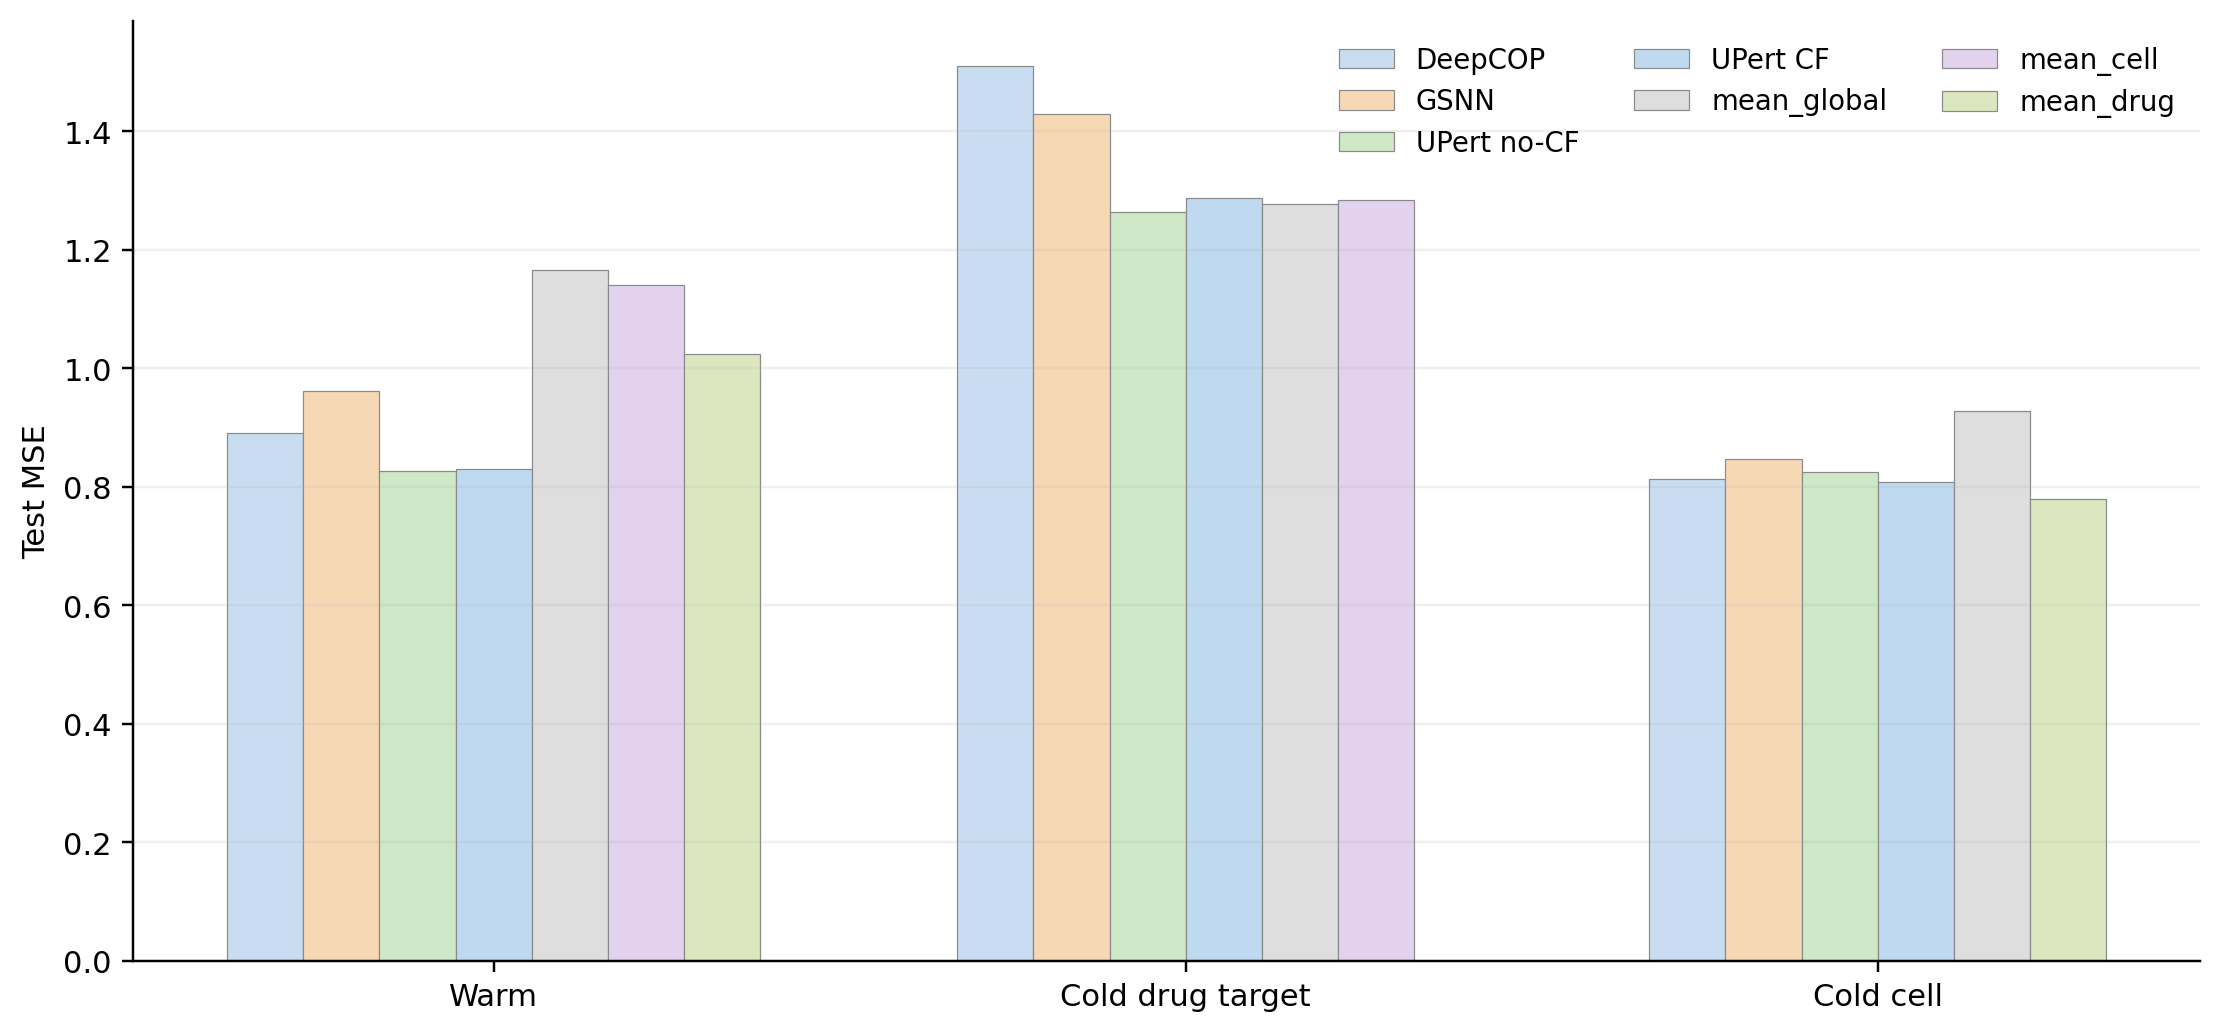

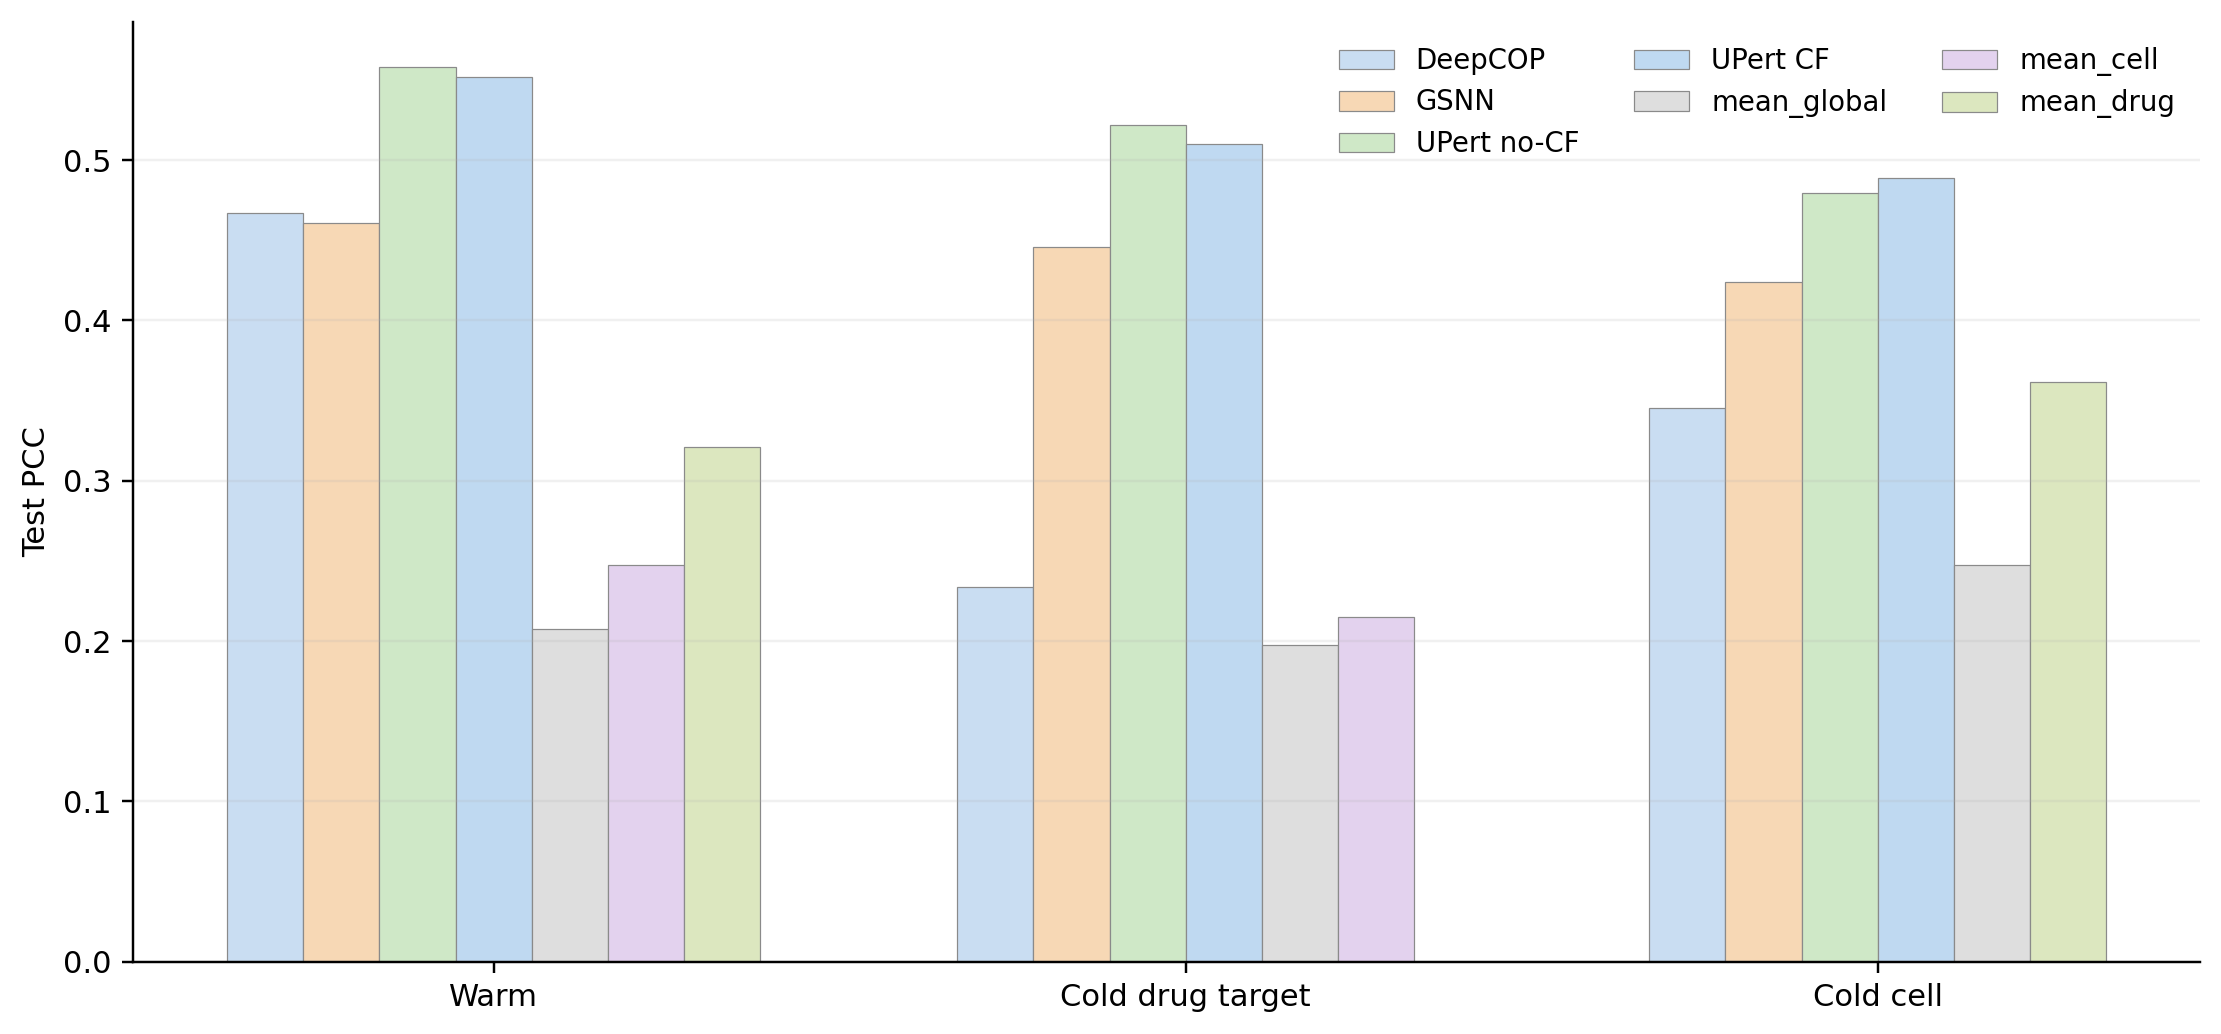

In [6]:
benchmark_paths = generate_benchmark_mean_baseline_figures.generate_all()
show_paths(benchmark_paths)
show_image(FIG_DIR / "benchmark_mse_with_mean_baselines.png", width=980)
show_image(FIG_DIR / "benchmark_pcc_with_mean_baselines.png", width=980)


## 7. True vs Predicted


/Users/liuxi/Desktop/UPert/liuthesis_my/figures/gene_expr_true_pred_all_models_by_split.png


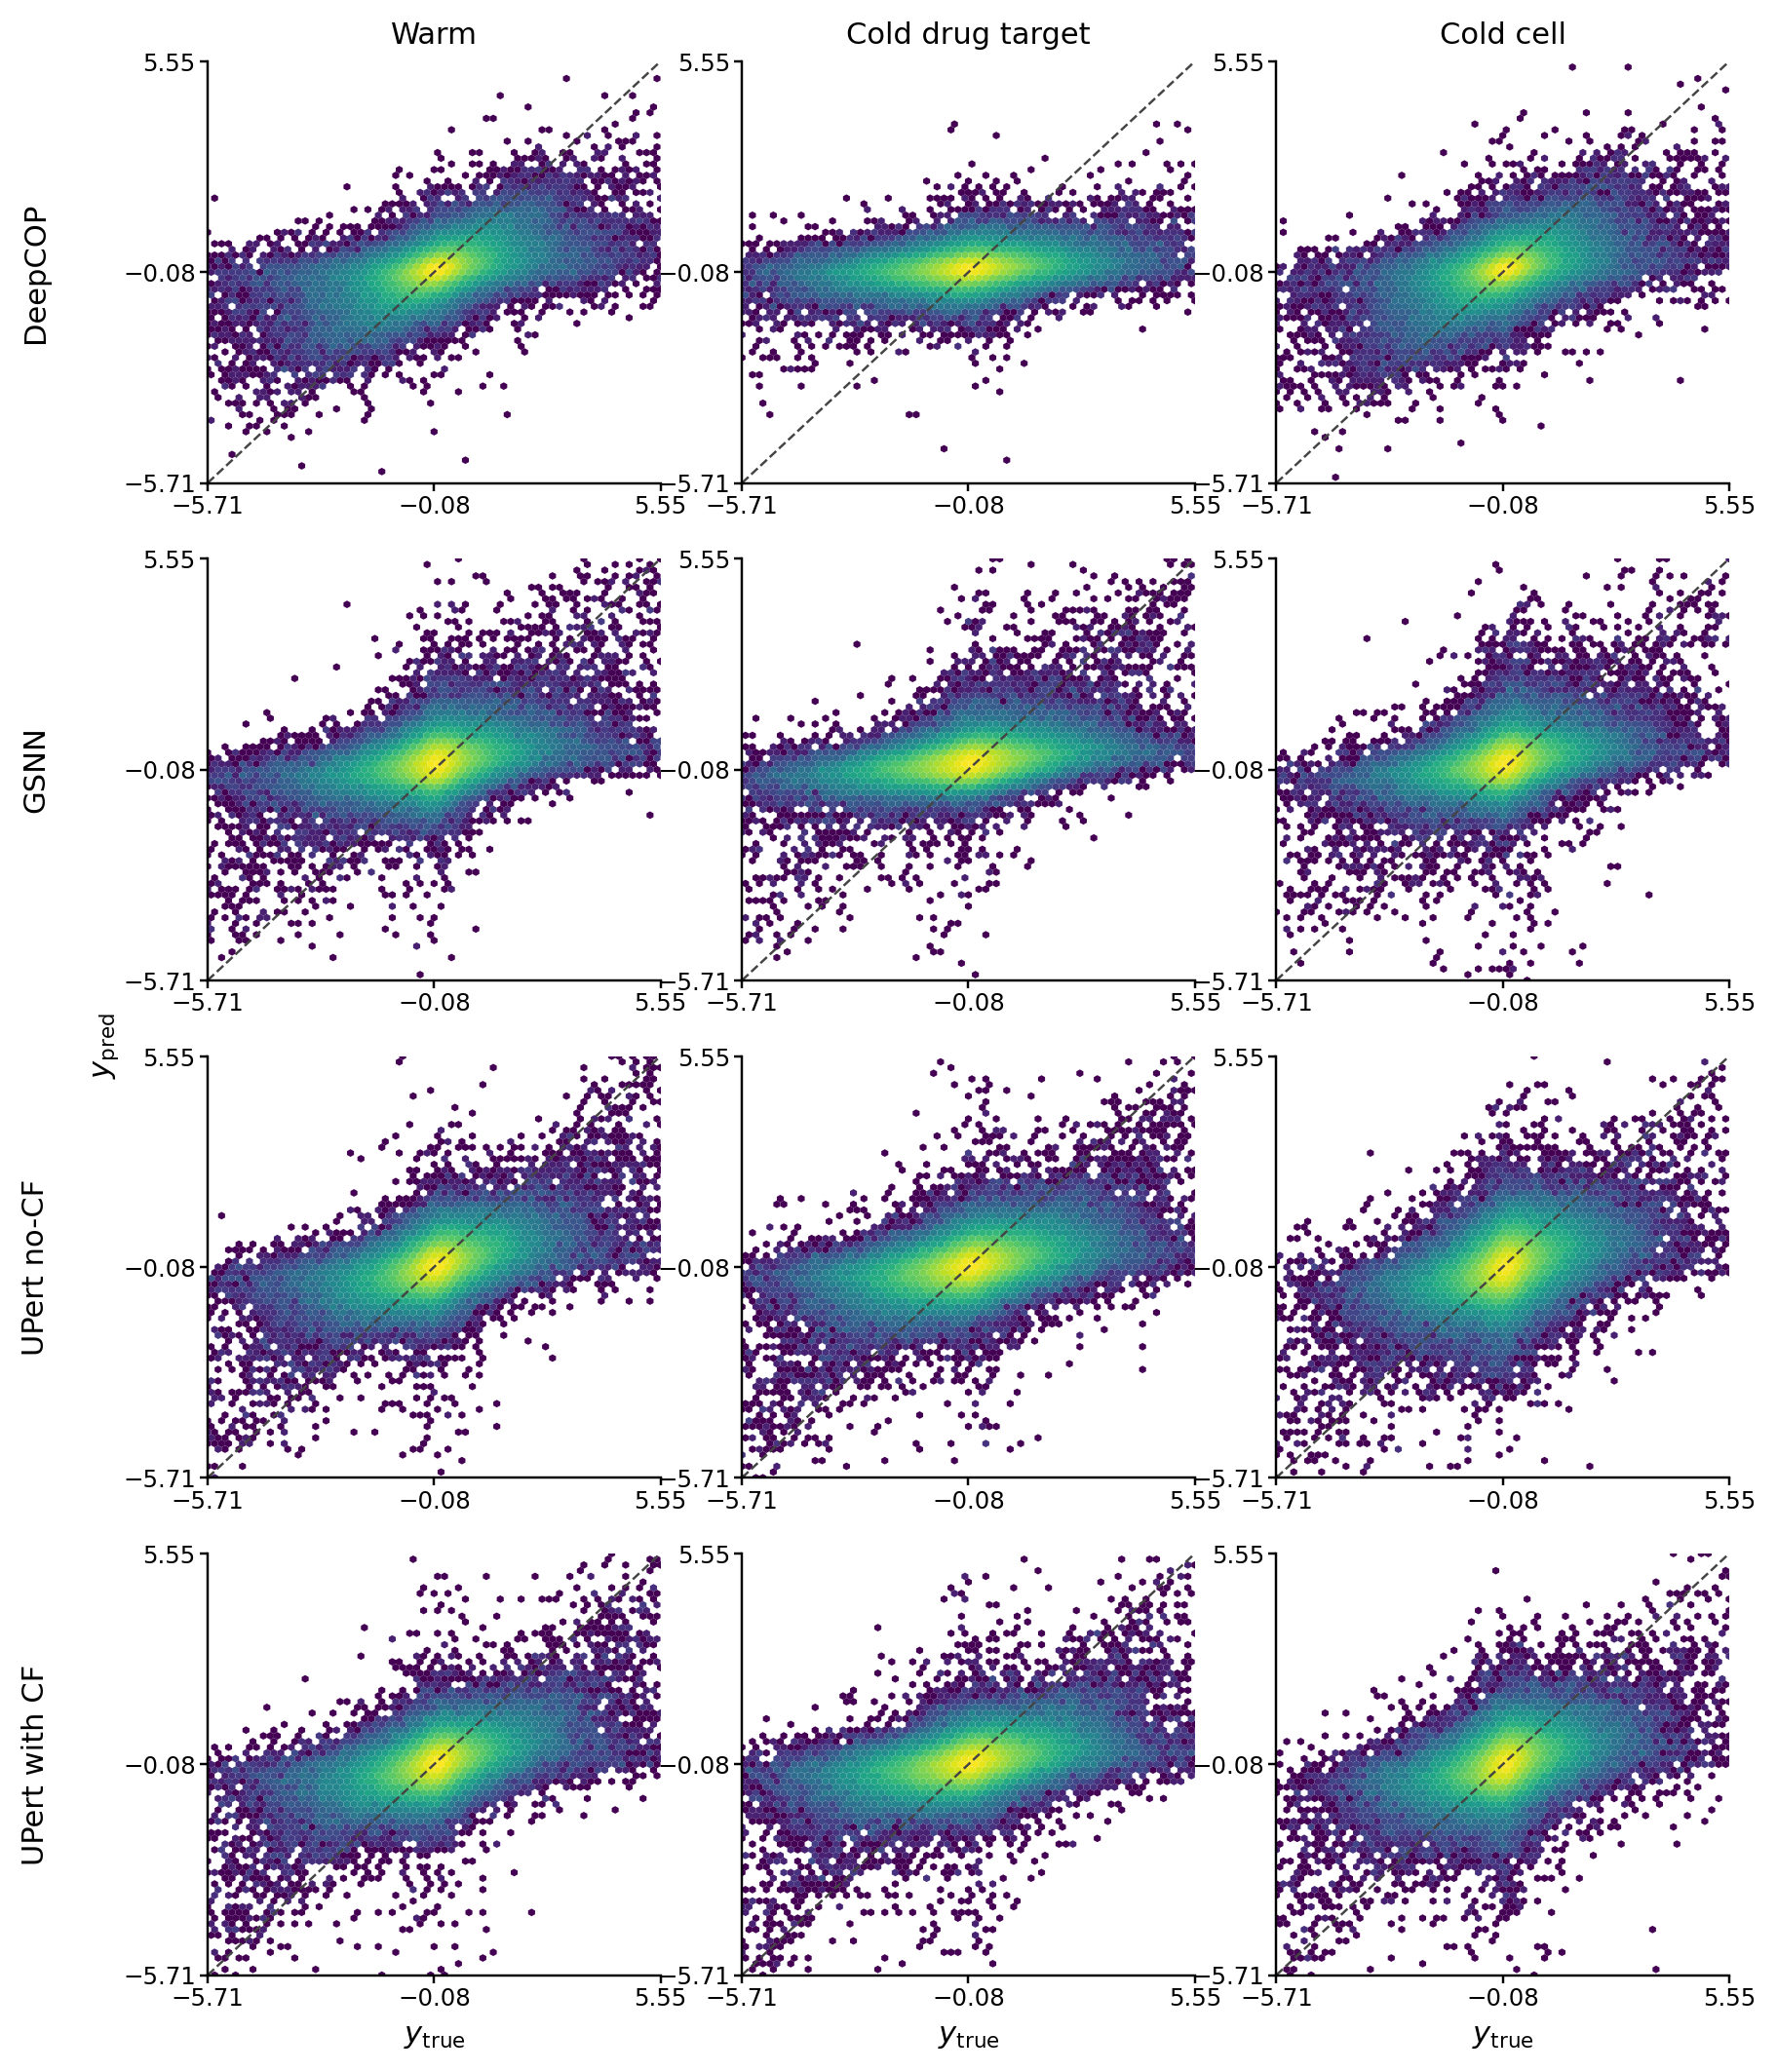

In [7]:
true_pred_path = plot_benchmark_scatter.generate()
show_paths([true_pred_path])
show_image(true_pred_path, width=980)


## 8. Gene Distribution


/Users/liuxi/Desktop/UPert/liuthesis_my/figures/xpert_style_gene_distribution.png
/Users/liuxi/Desktop/UPert/liuthesis_my/figures/xpert_style_gene_distribution.pdf


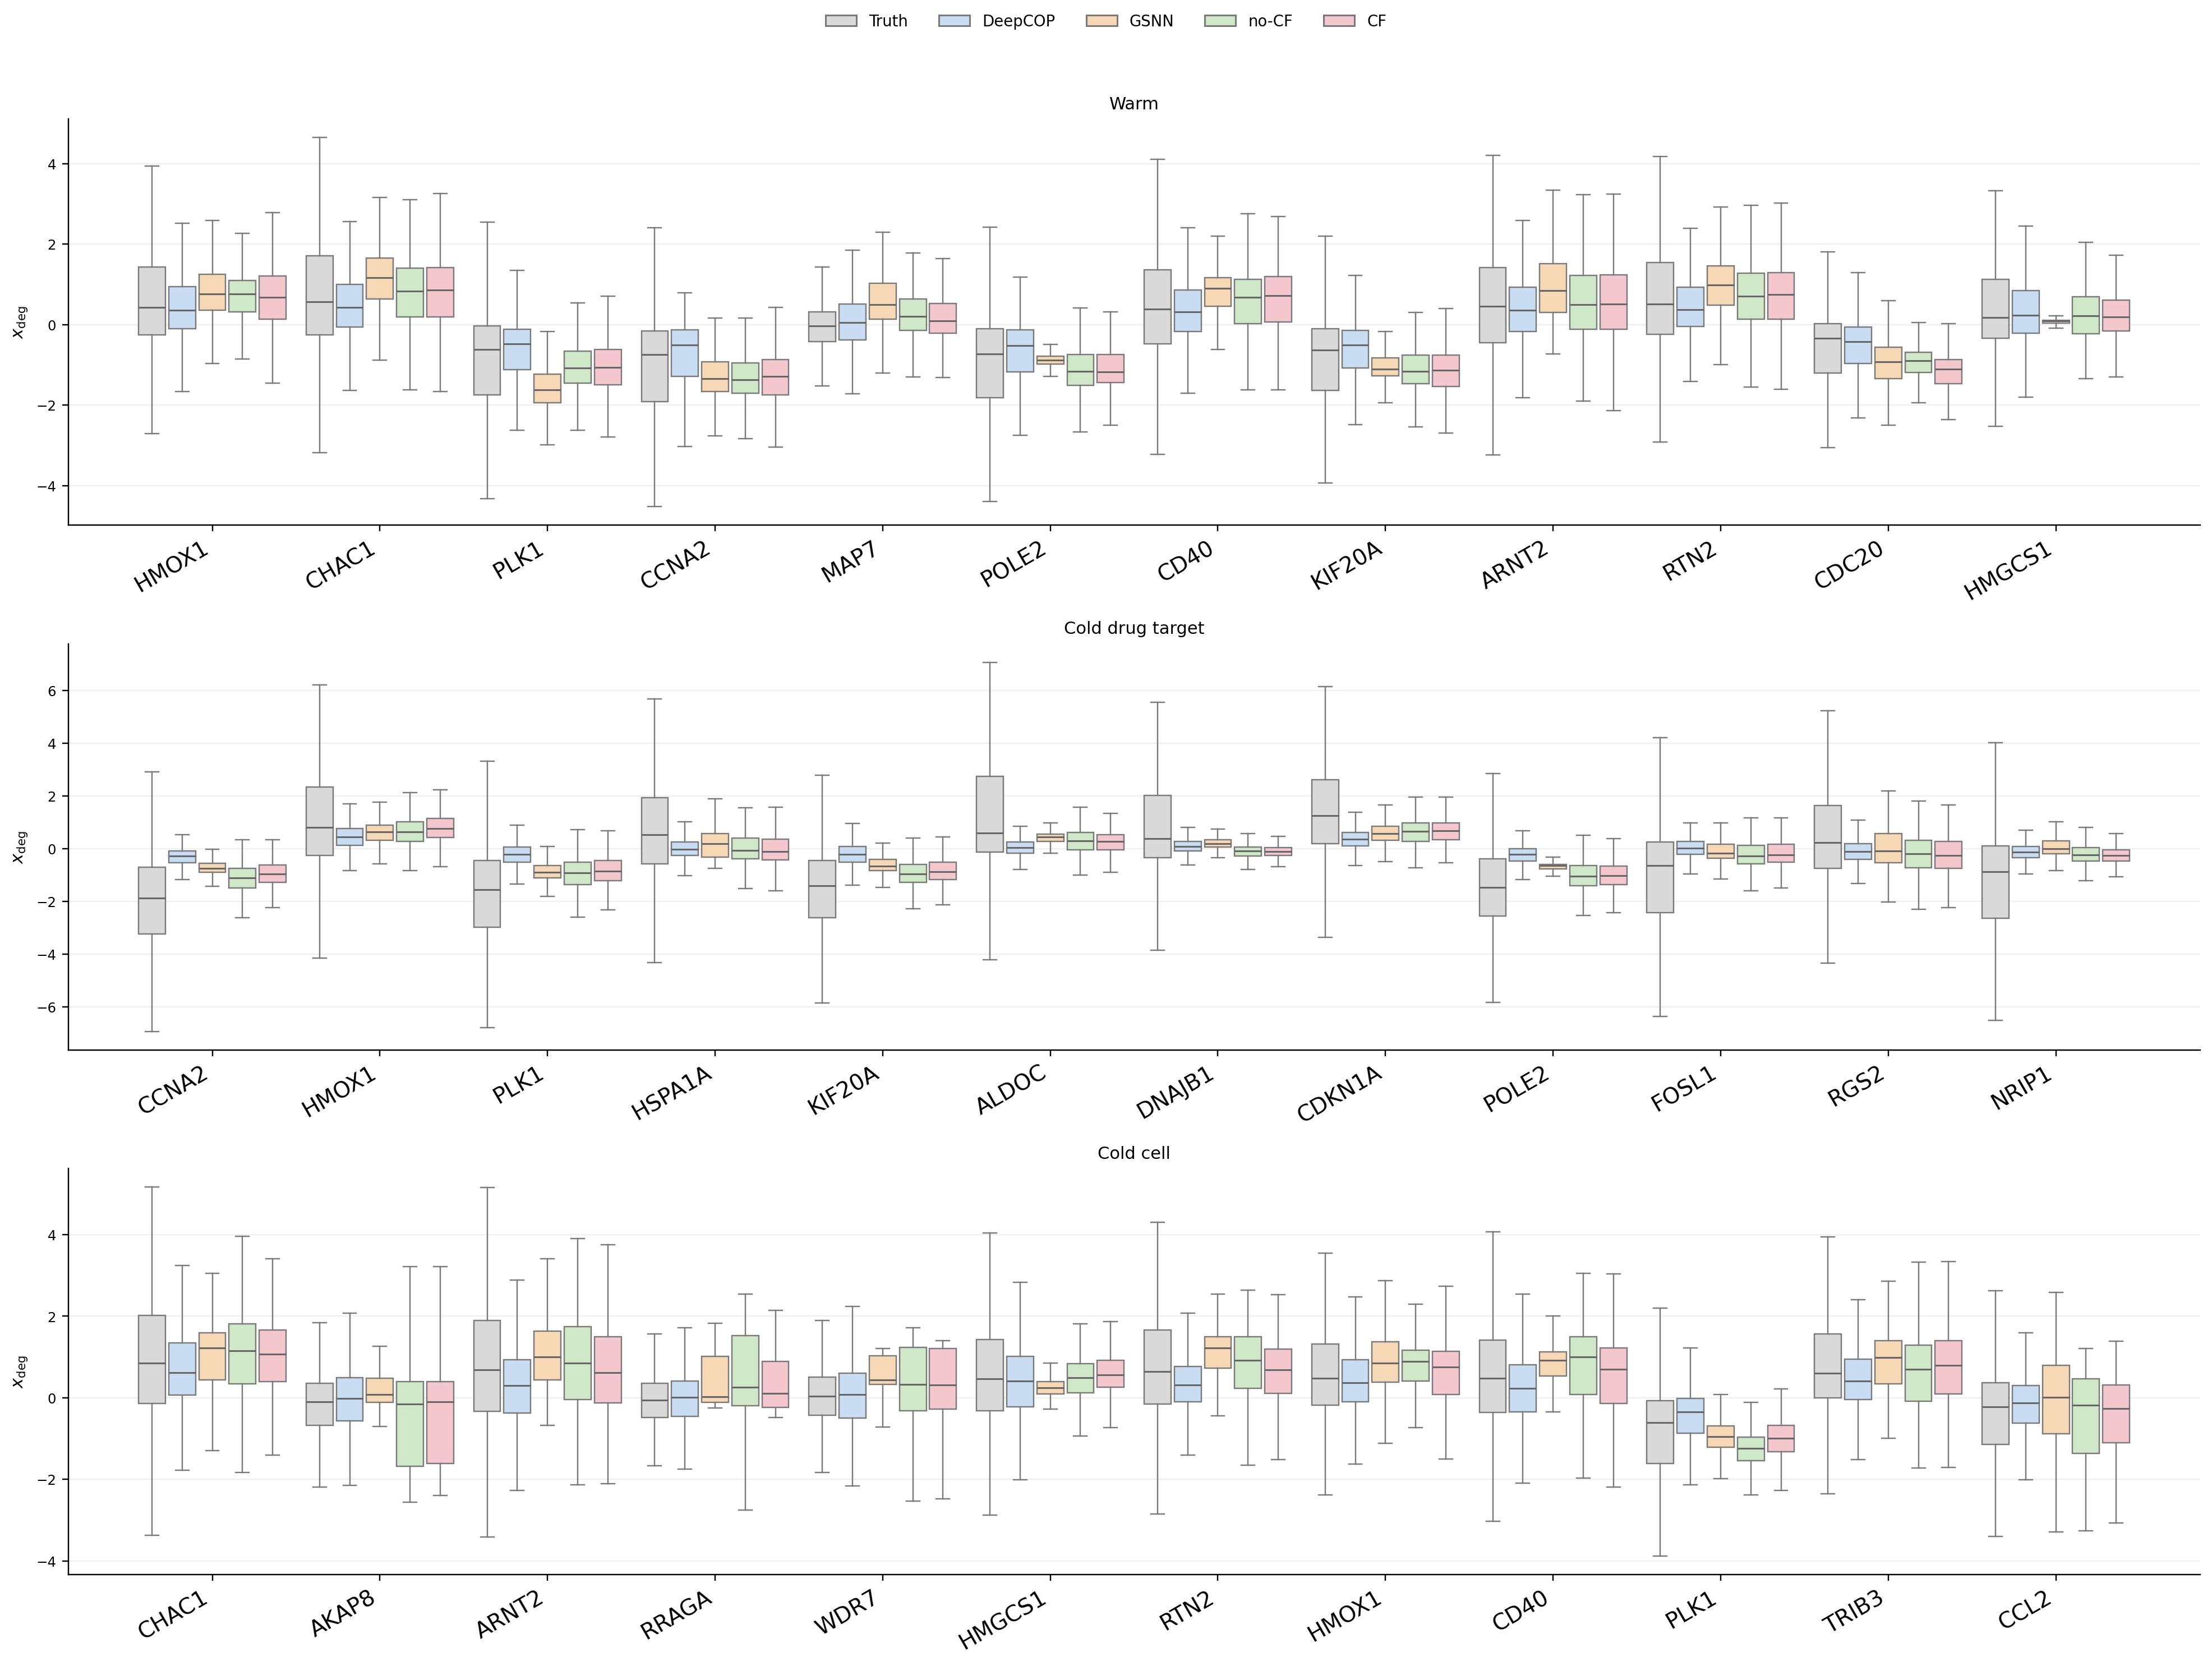

In [8]:
gene_distribution_paths = generate_gene_distribution_figure.generate()
show_paths(gene_distribution_paths)
show_image(gene_distribution_paths[0], width=1280)


## 9. Uncertainty


/Users/liuxi/Desktop/UPert/liuthesis_my/figures/uncertainty_summary_placeholder.png
/Users/liuxi/Desktop/UPert/liuthesis_my/figures/uncertainty_summary_placeholder.pdf
/Users/liuxi/Desktop/UPert/liuthesis_my/figures/uncertainty_case_study_placeholder.png
/Users/liuxi/Desktop/UPert/liuthesis_my/figures/uncertainty_case_study_placeholder.pdf


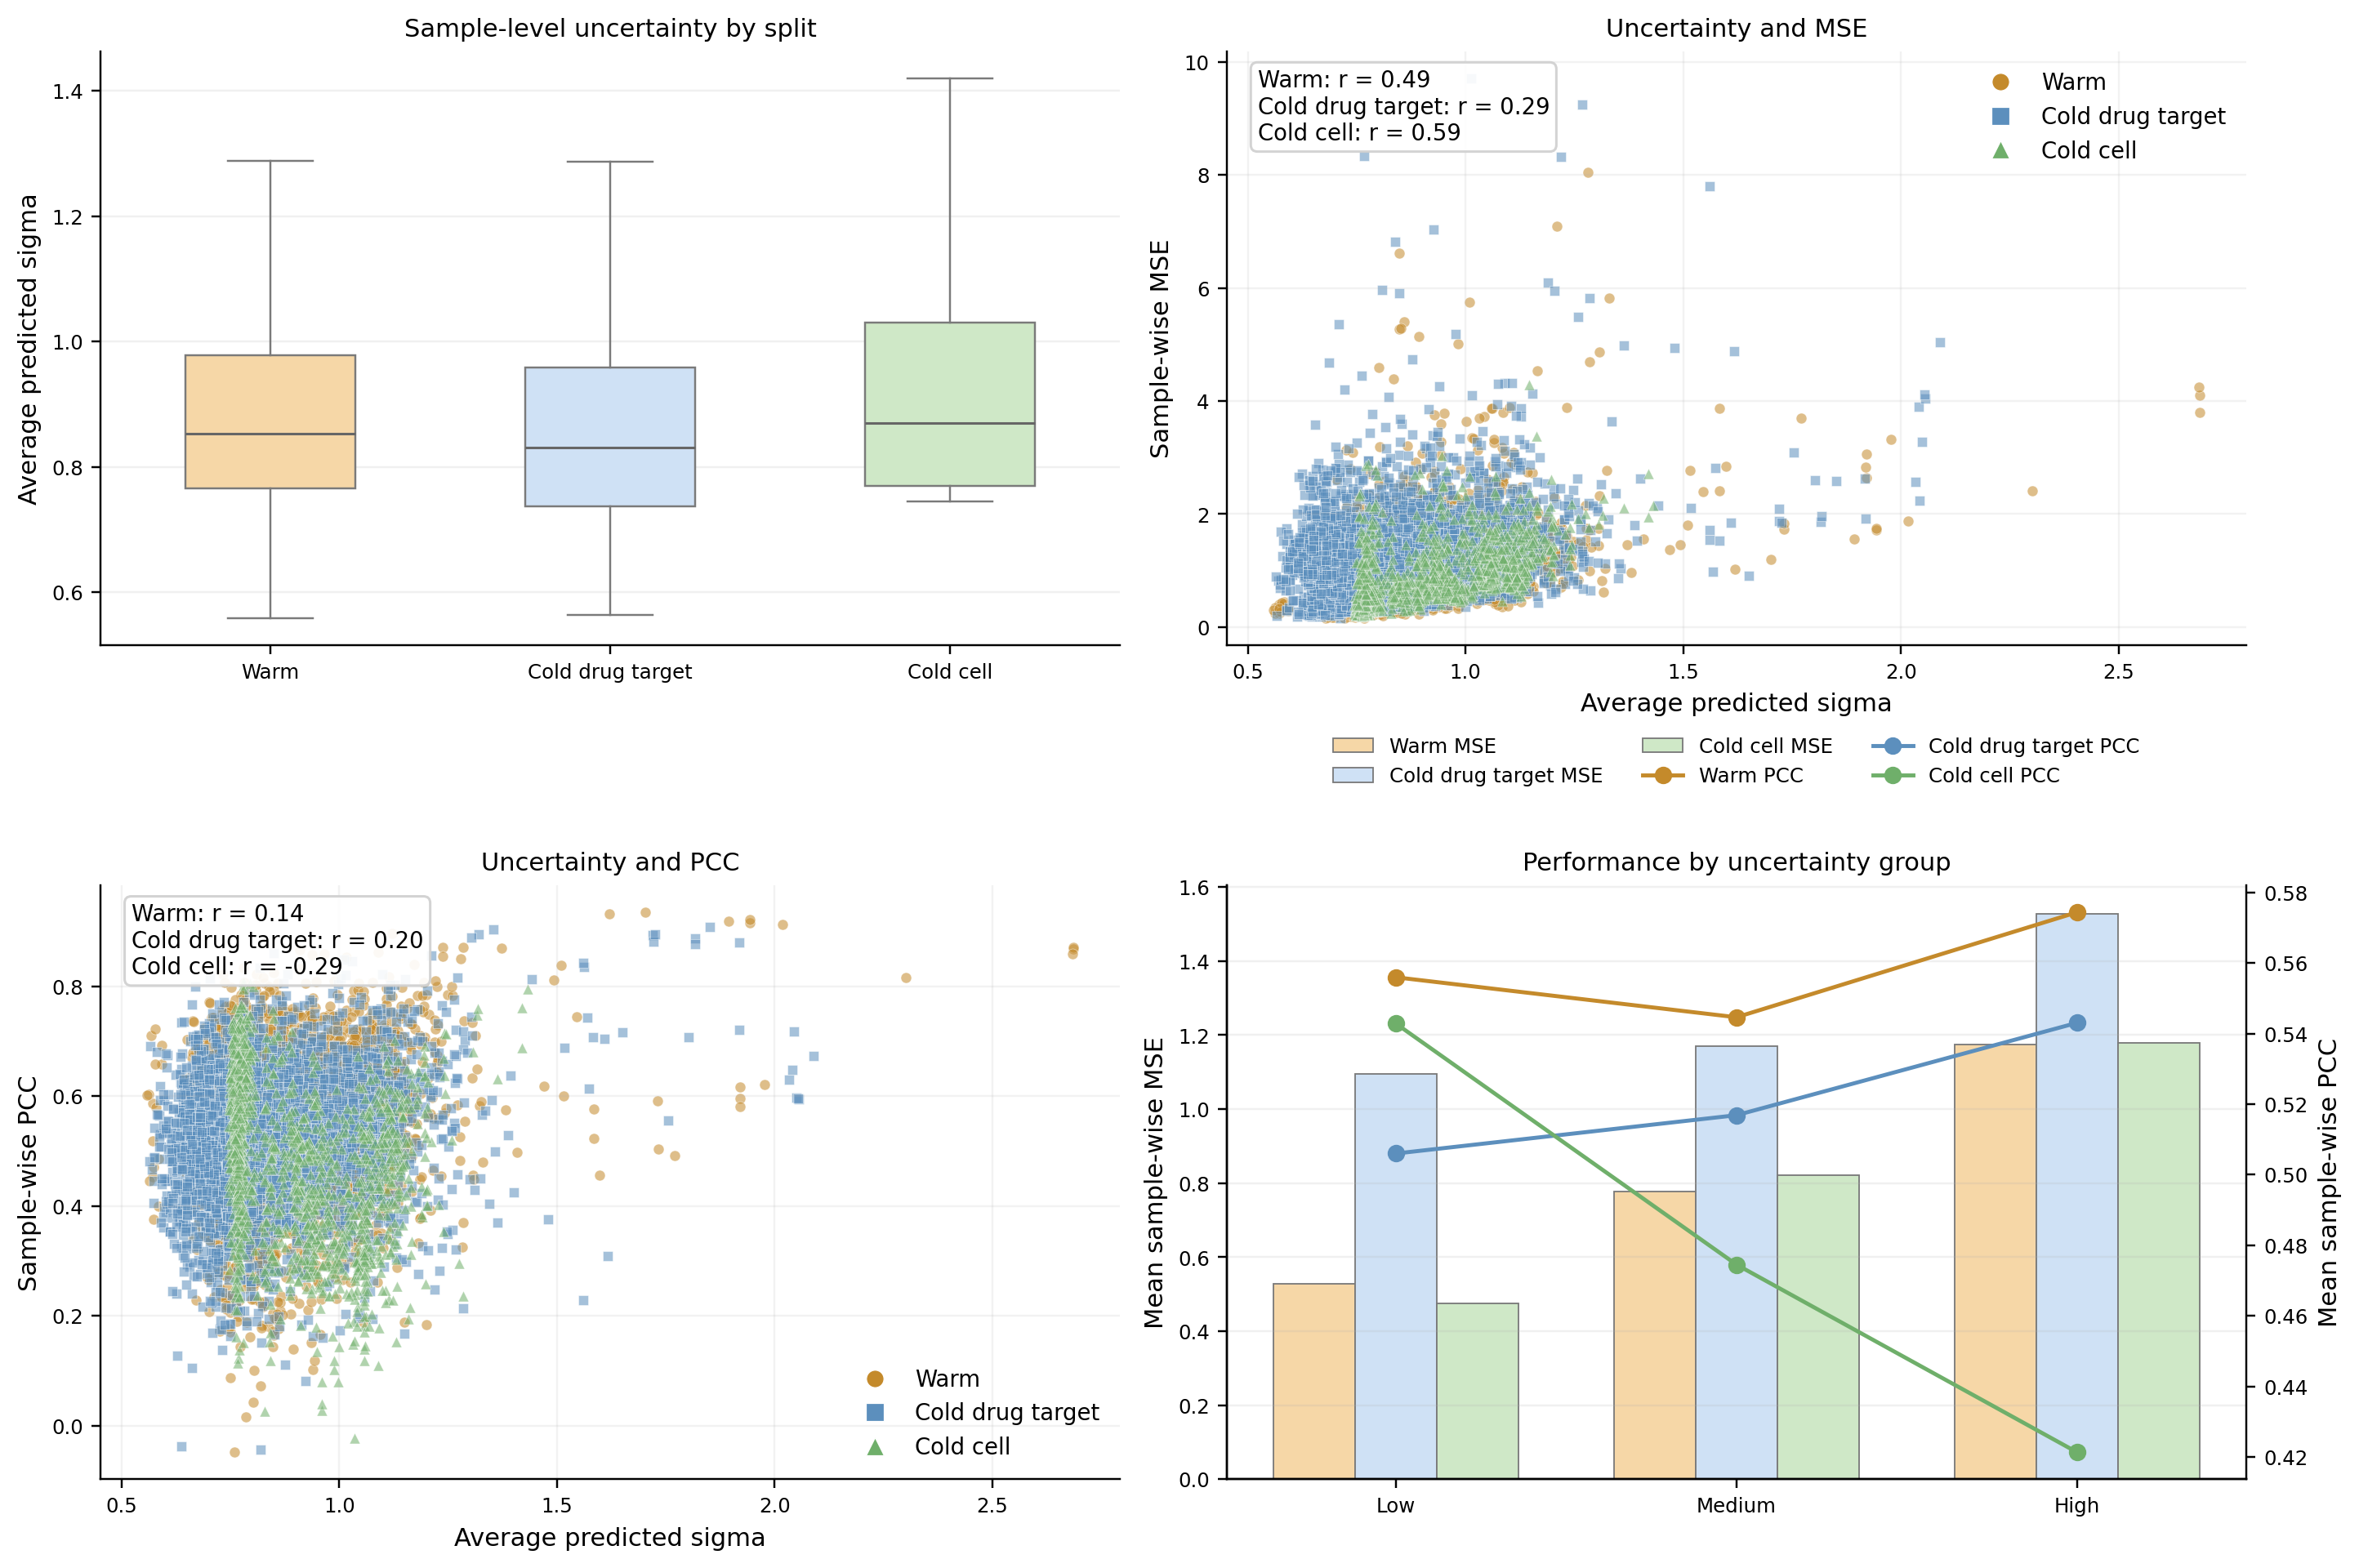

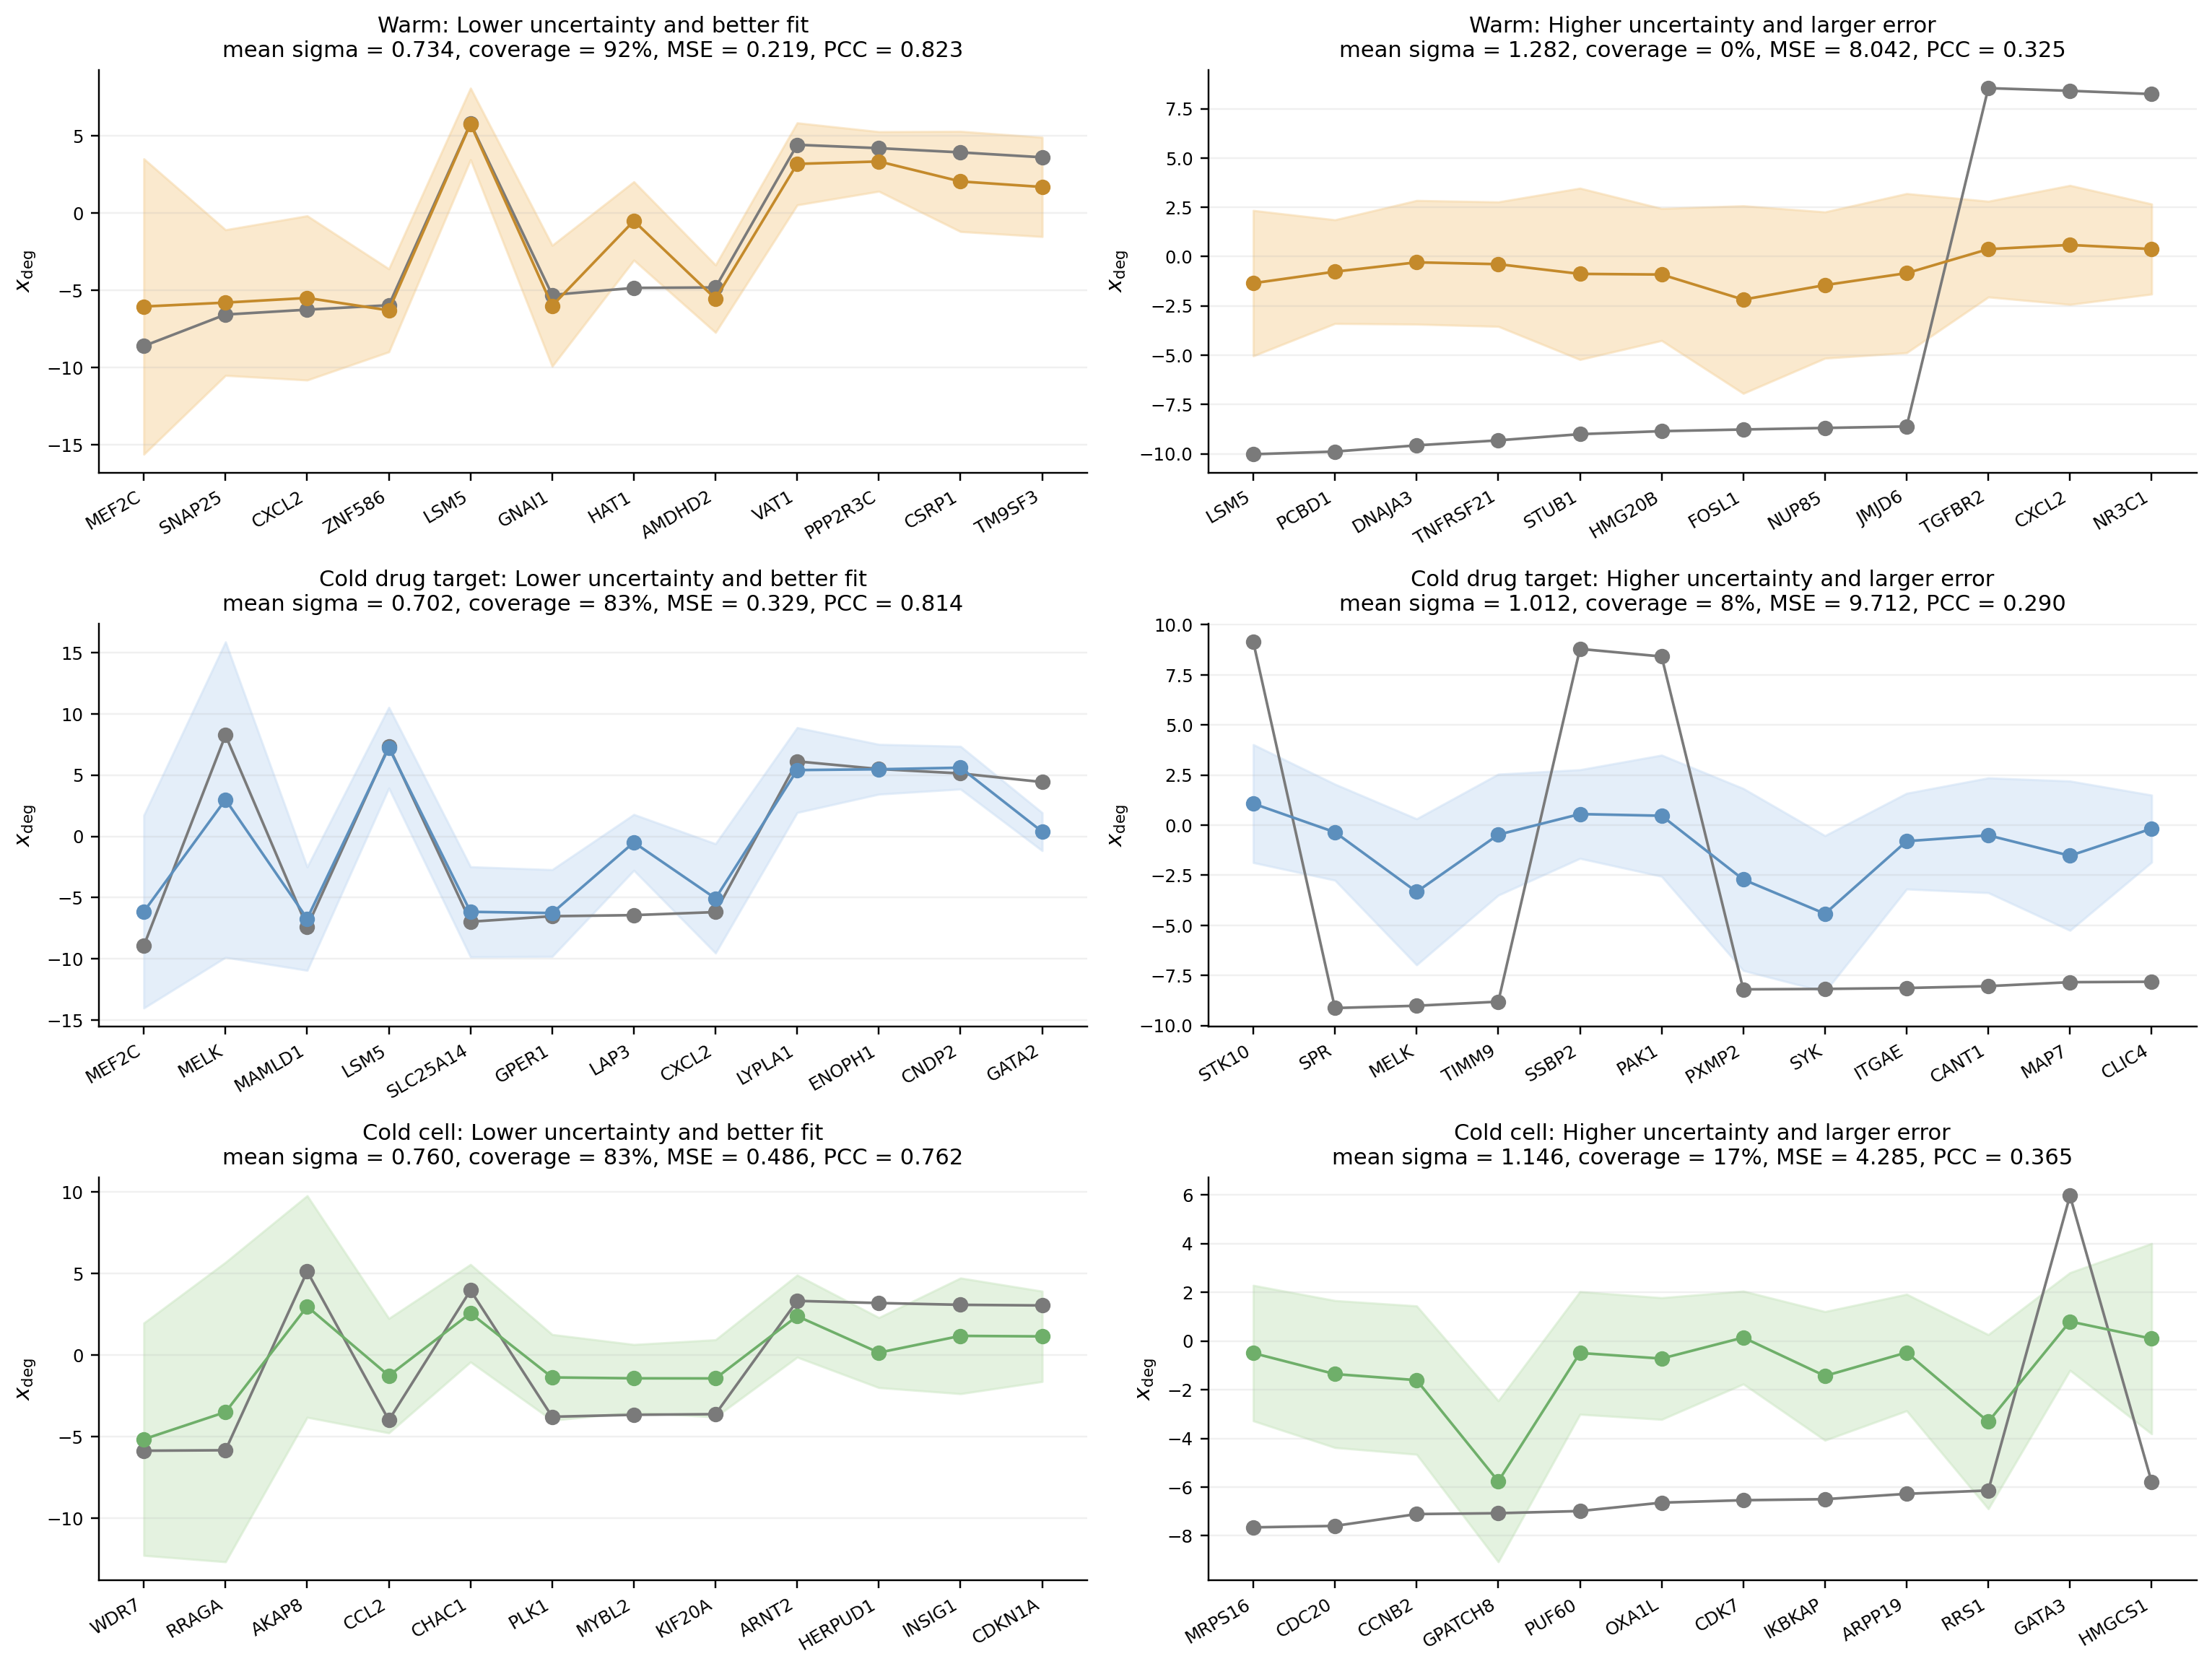

In [9]:
uncertainty_paths = generate_uncertainty_figures.generate_all()
show_paths(uncertainty_paths)
show_image(FIG_DIR / "uncertainty_summary_placeholder.png", width=1100)
show_image(FIG_DIR / "uncertainty_case_study_placeholder.png", width=1100)


## 10. Per-Gene Uncertainty


/Users/liuxi/Desktop/UPert/liuthesis_my/figures/gene_level_uncertainty_warm.png
/Users/liuxi/Desktop/UPert/liuthesis_my/figures/gene_level_uncertainty_warm.pdf


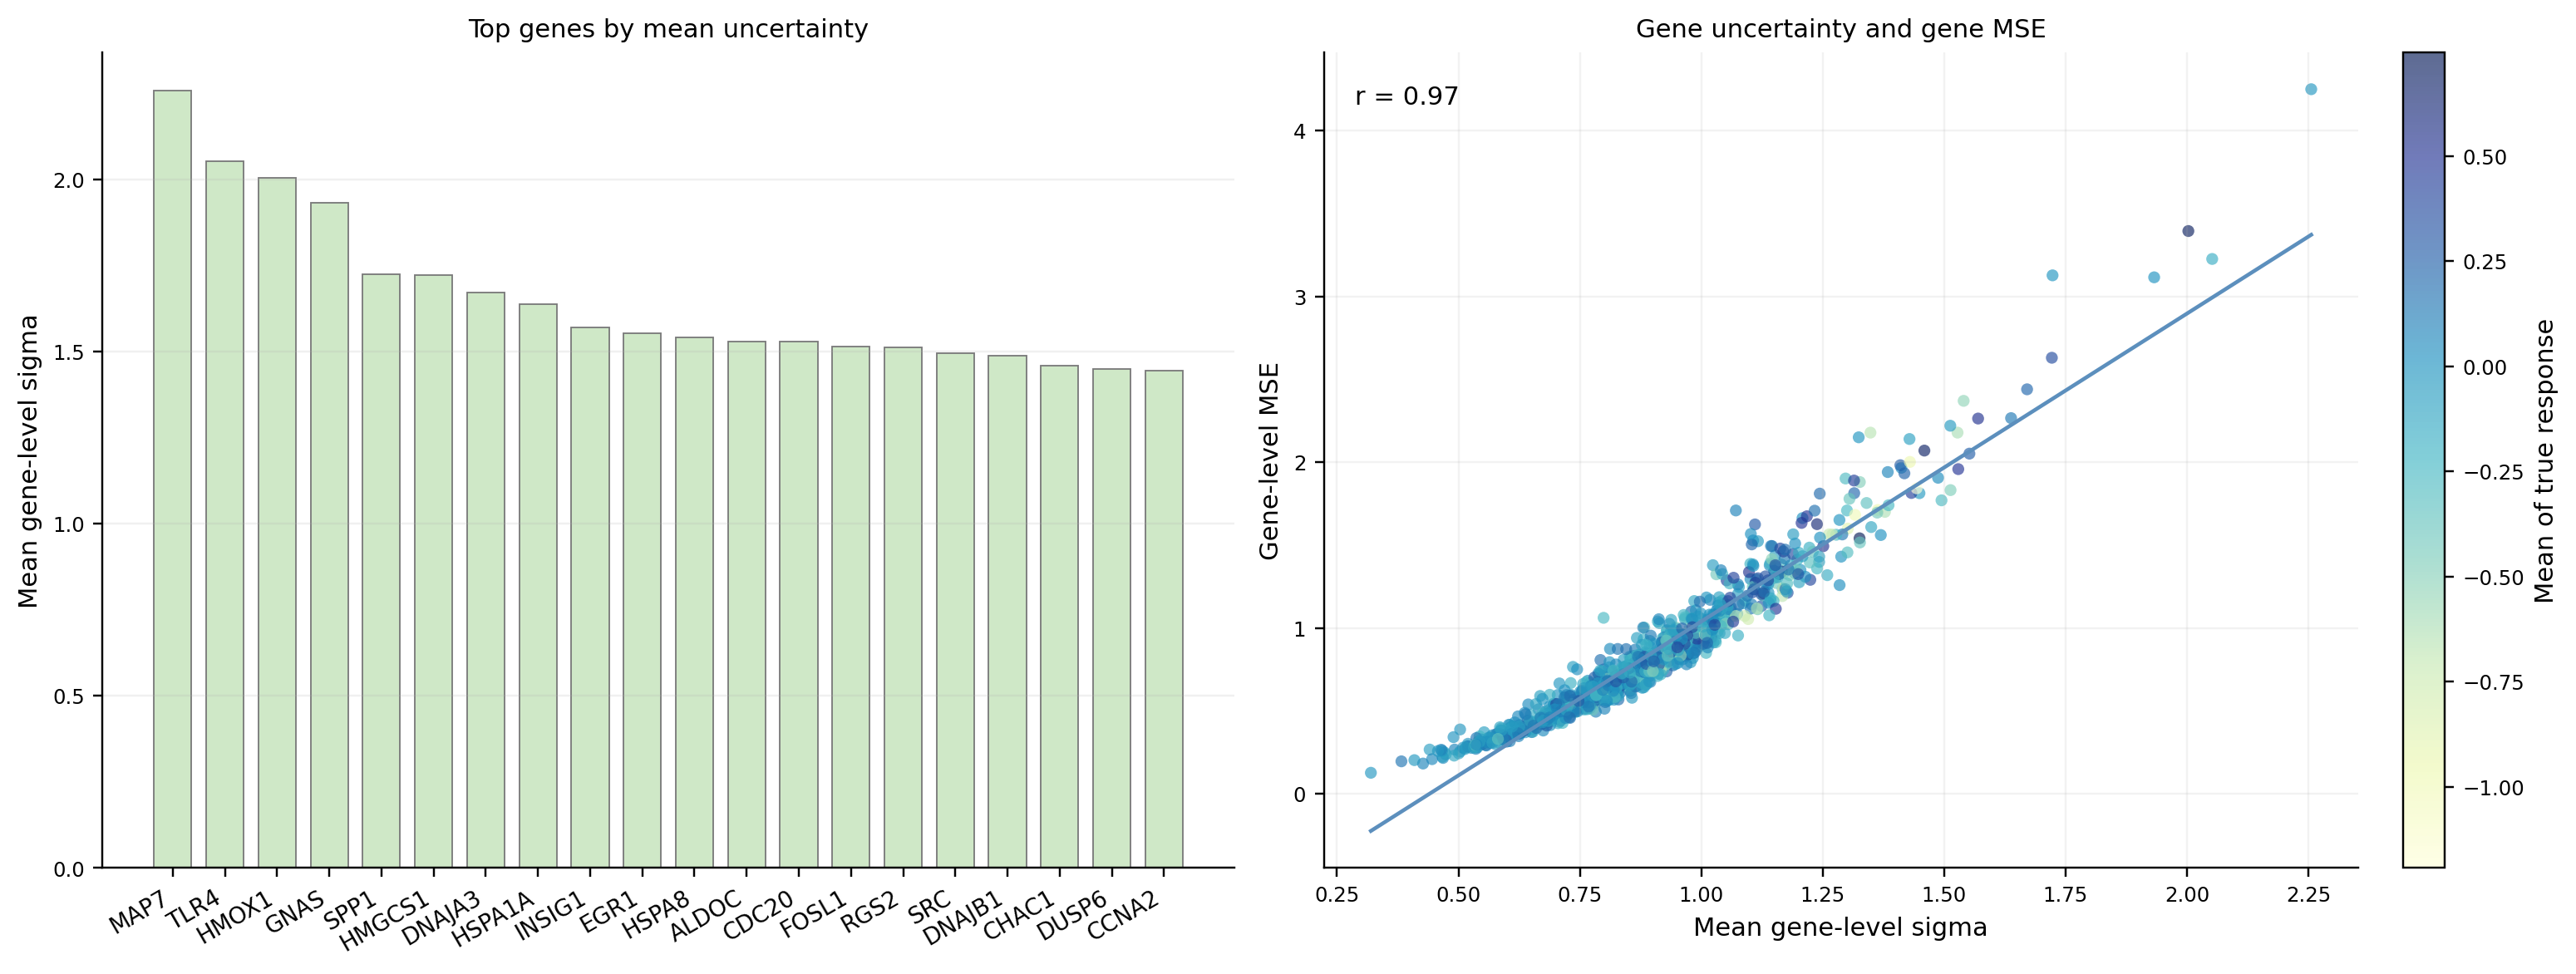

In [10]:
gene_uncertainty_paths = generate_gene_level_uncertainty_figure.generate()
show_paths(gene_uncertainty_paths)
show_image(gene_uncertainty_paths[0], width=980)


## 11. Data Efficiency


/Users/liuxi/Desktop/UPert/liuthesis_my/figures/data_efficiency_warm_real.png
/Users/liuxi/Desktop/UPert/liuthesis_my/figures/data_efficiency_warm_real.pdf


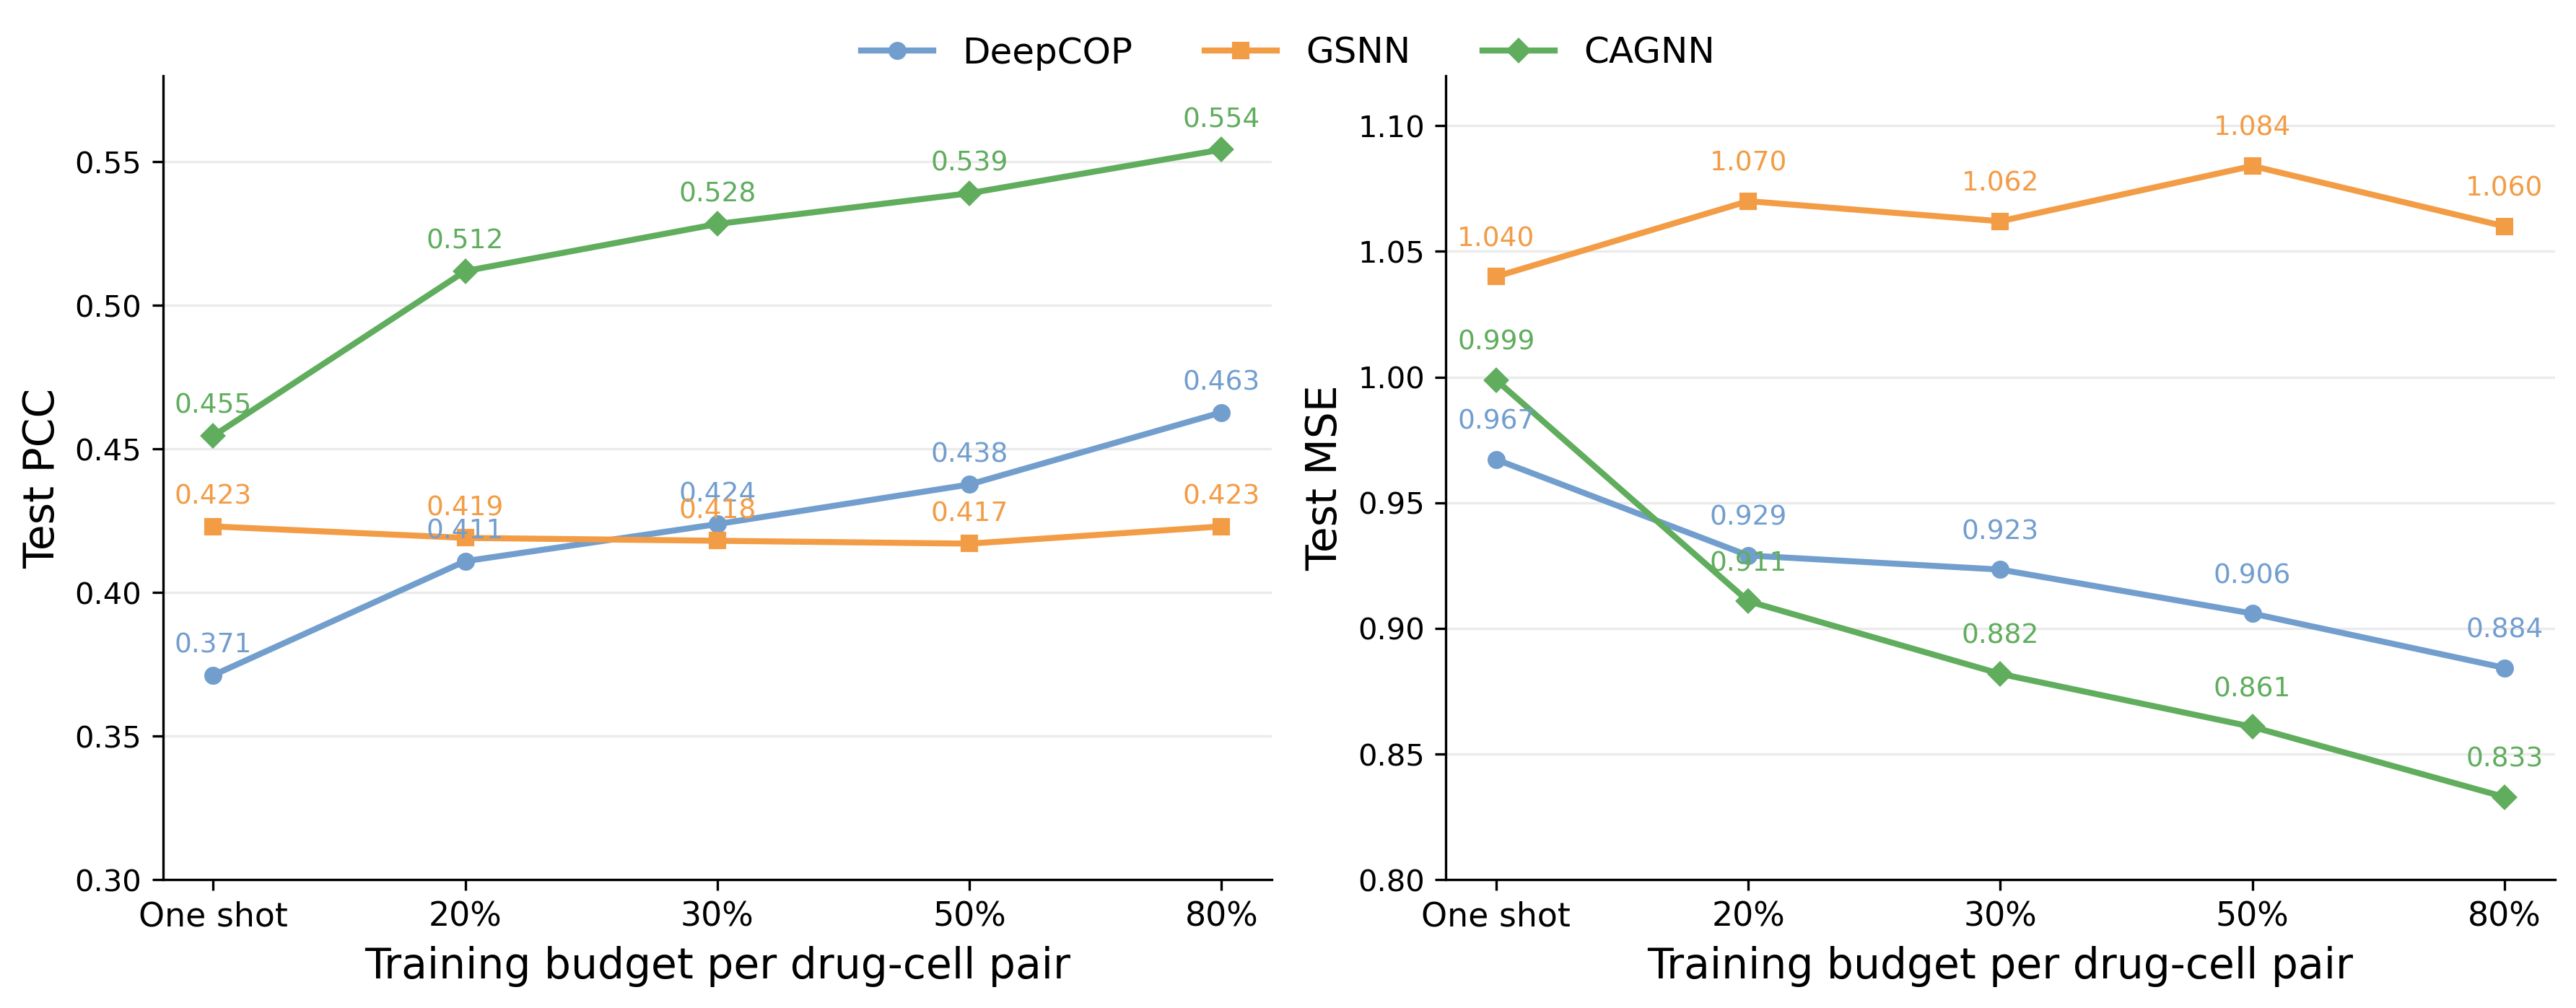

In [11]:
data_efficiency_paths = generate_data_efficiency_figure.generate()
show_paths(data_efficiency_paths)
show_image(data_efficiency_paths[0], width=1050)
